# P3 · Modelo predictivo end-to-end
## Dataset: Airbnb Buenos Aires — listings_clean.csv (desde P1)
**Objetivo:** Clasificar propiedades según su frecuencia de arriendo
(alta vs baja) usando modelos de ML clásicos y una red neuronal con Keras.

## Estructura

1. Carga y exploración inicial
2. Feature engineering
3. Preparación del dataset (train/val/test)
4. Modelos clásicos: regresión logística, árboles, XGBoost, LightGBM
5. Evaluación rigurosa: ROC-AUC, F1, matriz de confusión
6. Interpretación: importancia de variables
7. Red neuronal con Keras
8. Comparativa final: clásicos vs Keras

## 1. Carga y exploración inicial (Markdown)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/listings_clean.csv")
df["first_review"] = pd.to_datetime(df["first_review"])
df["last_review"] = pd.to_datetime(df["last_review"])
df["last_scraped"] = pd.to_datetime(df["last_scraped"])

print(df.shape)

(27348, 72)


## Variable objetivo

In [6]:
# Creamos la variable objetivo: alta_frecuencia
# 1 si reviews_per_month está sobre la mediana, 0 si está bajo
# Solo para propiedades con reseñas

df_modelo = df[df["tiene_resenas"] == 1].copy()

mediana_reviews = df_modelo["reviews_per_month"].median()
df_modelo["alta_frecuencia"] = (df_modelo["reviews_per_month"] > mediana_reviews).astype(int)

print(f"Mediana de reviews_per_month: {mediana_reviews:.2f}")
print(f"\nDistribución de la variable Objetivo:")
print(df_modelo["alta_frecuencia"].value_counts())
print(f"\nBalance: {df_modelo["alta_frecuencia"].mean():.2%}")

Mediana de reviews_per_month: 1.00

Distribución de la variable Objetivo:
alta_frecuencia
0    12282
1    11763
Name: count, dtype: int64

Balance: 48.92%


## 2. Feature engineering

In [8]:
features = ["room_type", "bathrooms", "beds", "review_scores_rating",
            "neighbourhood_cleansed", "antiguedad_total", "accommodates"]

df_modelo_feature = df_modelo[features + ["alta_frecuencia"]].dropna()

print(f"Shape: {df_modelo_feature.shape}")
print(f"Balance: {df_modelo_feature['alta_frecuencia'].mean():.2%}")

Shape: (24045, 8)
Balance: 48.92%


In [9]:
# One-hot Encoding para variables categóricas

df_encoded = pd.get_dummies(
    df_modelo_feature,
    columns = ["room_type", "neighbourhood_cleansed"],
    drop_first = True
)

print(f"Shape antes: {df_modelo_feature.shape}")
print(f"Shape después: {df_encoded.shape}")
print(f"Columnas nuevas: {df_encoded.shape[1] - df_modelo_feature.shape[1]}")

Shape antes: (24045, 8)
Shape después: (24045, 55)
Columnas nuevas: 47


## 3. Preparación del dataset (train/val/test)

In [11]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop(columns=["alta_frecuencia"])
y = df_encoded["alta_frecuencia"]

# Split: 70% train, 15% val, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size = 0.30, random_state = 42, stratify = y
    )
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size = 0.50, random_state = 42, stratify = y_temp)

print(f"Train: {X_train.shape[0]:,} filas ({X_train.shape[0]/len(X):.0%})")
print(f"Val:   {X_val.shape[0]:,} filas ({X_val.shape[0]/len(X):.0%})")
print(f"Test:  {X_test.shape[0]:,} filas ({X_test.shape[0]/len(X):.0%})")


Train: 16,831 filas (70%)
Val:   3,607 filas (15%)
Test:  3,607 filas (15%)


In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

## 4. Modelos clásicos

### Regresión Logística

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, f1_score, classification_report

# Baseline: regresión logística
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

# Evaluación en validación
y_pred_lr = lr.predict(X_val_scaled)      
y_prob_lr = lr.predict_proba(X_val_scaled)[:, 1] 

print("=== Regresión Logística ===")
print(f"ROC-AUC: {roc_auc_score(y_val, y_prob_lr):.4f}")
print(f"F1:      {f1_score(y_val, y_pred_lr):.4f}")
print(f"\n{classification_report(y_val, y_pred_lr)}")

=== Regresión Logística ===
ROC-AUC: 0.6600
F1:      0.6405

              precision    recall  f1-score   support

           0       0.65      0.57      0.61      1843
           1       0.60      0.68      0.64      1764

    accuracy                           0.62      3607
   macro avg       0.63      0.63      0.62      3607
weighted avg       0.63      0.62      0.62      3607



### XGBoost

In [16]:
from xgboost import XGBClassifier

xgb = XGBClassifier (random_state=42, eval_metric="logloss")
xgb.fit(X_train_scaled, y_train)

y_pred_xgb = xgb.predict(X_val_scaled)
y_prob_xgb = xgb.predict_proba(X_val_scaled)[:,1]

print("=== XGBoost ===")
print(f"ROC-AUC: {roc_auc_score(y_val, y_prob_xgb):.4f}")
print(f"F1:      {f1_score(y_val, y_pred_xgb):.4f}")
print(f"\n{classification_report(y_val, y_pred_xgb)}")

=== XGBoost ===
ROC-AUC: 0.8277
F1:      0.7372

              precision    recall  f1-score   support

           0       0.75      0.72      0.74      1843
           1       0.72      0.76      0.74      1764

    accuracy                           0.74      3607
   macro avg       0.74      0.74      0.74      3607
weighted avg       0.74      0.74      0.74      3607



### LightGBM

In [18]:
import lightgbm as lgb

lgbm = lgb.LGBMClassifier (random_state=42)
lgbm.fit(X_train_scaled, y_train)

y_pred_lgbm = lgbm.predict(X_val_scaled)
y_prob_lgbm = lgbm.predict_proba(X_val_scaled)[:, 1]

print("=== LightGBM ===")
print(f"ROC-AUC: {roc_auc_score(y_val, y_prob_xgb):.4f}")
print(f"F1:      {f1_score(y_val, y_pred_xgb):.4f}")
print(f"\n{classification_report(y_val, y_pred_xgb)}")

[LightGBM] [Info] Number of positive: 8234, number of negative: 8597
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000929 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 506
[LightGBM] [Info] Number of data points in the train set: 16831, number of used features: 41
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.489216 -> initscore=-0.043141
[LightGBM] [Info] Start training from score -0.043141
=== LightGBM ===
ROC-AUC: 0.8277
F1:      0.7372

              precision    recall  f1-score   support

           0       0.75      0.72      0.74      1843
           1       0.72      0.76      0.74      1764

    accuracy                           0.74      3607
   macro avg       0.74      0.74      0.74      3607
weighted avg       0.74      0.74      0.74      3607



c:\Users\jaime\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\jaime\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


### Árbol de decisión

In [19]:
from sklearn.tree import DecisionTreeClassifier 

tree = DecisionTreeClassifier(random_state=42, max_depth=5)
tree.fit(X_train_scaled, y_train)

y_pred_tree = tree.predict(X_val_scaled)
y_prob_tree = tree.predict_proba(X_val_scaled)[:,1]

print("=== Árbol de decisión ===")
print(f"ROC-AUC: {roc_auc_score(y_val, y_prob_tree):.4f}")
print(f"F1:      {f1_score(y_val, y_pred_tree):.4f}")
print(f"\n{classification_report(y_val, y_pred_tree)}")

=== Árbol de decisión ===
ROC-AUC: 0.7777
F1:      0.7259

              precision    recall  f1-score   support

           0       0.76      0.63      0.69      1843
           1       0.67      0.79      0.73      1764

    accuracy                           0.71      3607
   macro avg       0.71      0.71      0.71      3607
weighted avg       0.72      0.71      0.71      3607



### Tabla comparativa de modelos

In [20]:
resultados = {
    "Modelo": ["Regresión Logística", "Árbol de decisión", "XGBoost", "LightGBM"],
    "ROC-AUC": [
        roc_auc_score(y_val, y_prob_lr),
        roc_auc_score(y_val, y_prob_tree),
        roc_auc_score(y_val, y_prob_xgb),
        roc_auc_score(y_val, y_prob_lgbm)
    ],
    "F1": [
        f1_score(y_val, y_pred_lr),
        f1_score(y_val, y_pred_tree),
        f1_score(y_val, y_pred_xgb),
        f1_score(y_val, y_pred_lgbm)
    ],
}

df_resultados = pd.DataFrame(resultados).round(4)
print(df_resultados)

                Modelo  ROC-AUC      F1
0  Regresión Logística   0.6600  0.6405
1    Árbol de decisión   0.7777  0.7259
2              XGBoost   0.8277  0.7372
3             LightGBM   0.8331  0.7454


## 5. Evaluación rigurosa: ROC-AUC, F1, matriz de confusión

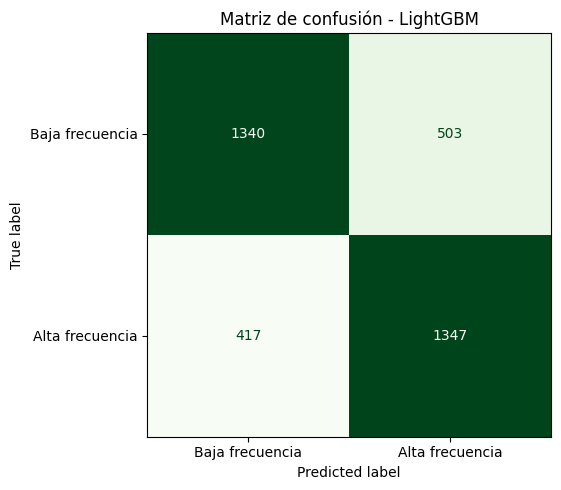

In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay    

# Matriz de confusión con LightGBM (mejor modelo)

cm = confusion_matrix(y_val,y_pred_lgbm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["Baja frecuencia", "Alta frecuencia"])

fig, ax = plt.subplots(figsize=(6,5))
disp.plot(ax=ax, colorbar=False, cmap="Greens")
ax.set_title("Matriz de confusión - LightGBM")
plt.tight_layout()
plt.show()

## 6. Importancia de variables

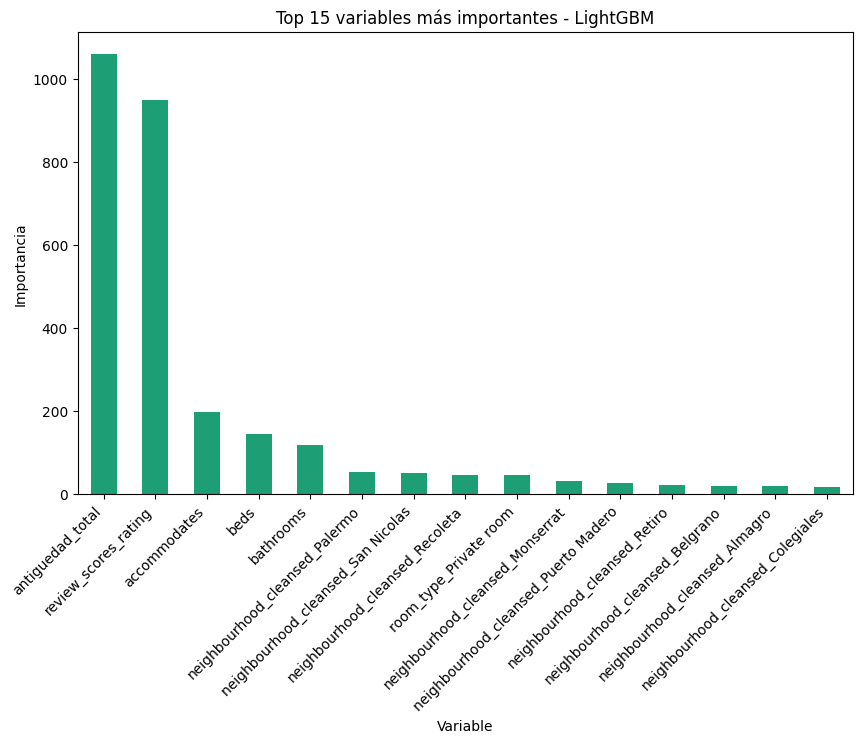

In [23]:
# Importancia de variables de LightGBM
importancias = pd.Series(
    lgbm.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10,6))
importancias.head(15).plot(kind="bar", ax=ax, color="#1D9E75")
ax.set_title("Top 15 variables más importantes - LightGBM")
ax.set_xlabel("Variable")
ax.set_ylabel("Importancia")
plt.xticks(rotation=45, ha="right")
plt.tight_layout
plt.show()

## Insight: importancia de variables

Las dos variables más predictivas son `antiguedad_total` y 
`review_scores_rating`, con importancia muy superior al resto.

Esto confirma que el algoritmo de Airbnb favorece propiedades 
establecidas con buenas evaluaciones: la antigüedad genera 
visibilidad acumulada y el score genera confianza en el huésped.

`accommodates` y `beds` ocupan el tercer y cuarto lugar, 
lo que sugiere que la capacidad de la propiedad tiene cierta 
relevancia pero mucho menor que la reputación.

**Recomendación accionable:** un anfitrión nuevo debe priorizar 
obtener buenas reseñas desde el primer día. La antigüedad se 
construye sola con el tiempo, pero el score depende de la 
calidad del servicio desde el inicio.

## 7. Red neuronal con Keras

In [25]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Fijamos semilla para reproductibilidad
tf.random.set_seed(42)

# Definimos la arquitectura de la red
modelo_keras = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

modelo_keras.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         3,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,633 (22.00 KB)

 Trainable params: 5,633 (22.00 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
# Compilar el modelo
modelo_keras.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Entrenar
historia = modelo_keras.fit(
    X_train_scaled, y_train,
    epochs=20,
    batch_size=256,
    validation_data=(X_val_scaled, y_val),
    verbose=1
)

Epoch 1/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5656 - loss: 0.6956 - val_accuracy: 0.6163 - val_loss: 0.6573
Epoch 2/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6238 - loss: 0.6456 - val_accuracy: 0.6257 - val_loss: 0.6505
Epoch 3/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6310 - loss: 0.6369 - val_accuracy: 0.6268 - val_loss: 0.6481
Epoch 4/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6334 - loss: 0.6324 - val_accuracy: 0.6304 - val_loss: 0.6458
Epoch 5/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6372 - loss: 0.6286 - val_accuracy: 0.6315 - val_loss: 0.6433
Epoch 6/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6419 - loss: 0.6250 - val_accuracy: 0.6332 - val_loss: 0.6402
Epoch 7/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6449 - loss: 0.6215 - val_accuracy: 0.6410 - val_loss: 0.6375
Epoch 8/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6493 - loss: 0.6179 - val_accuracy: 0.6443 - val_loss:

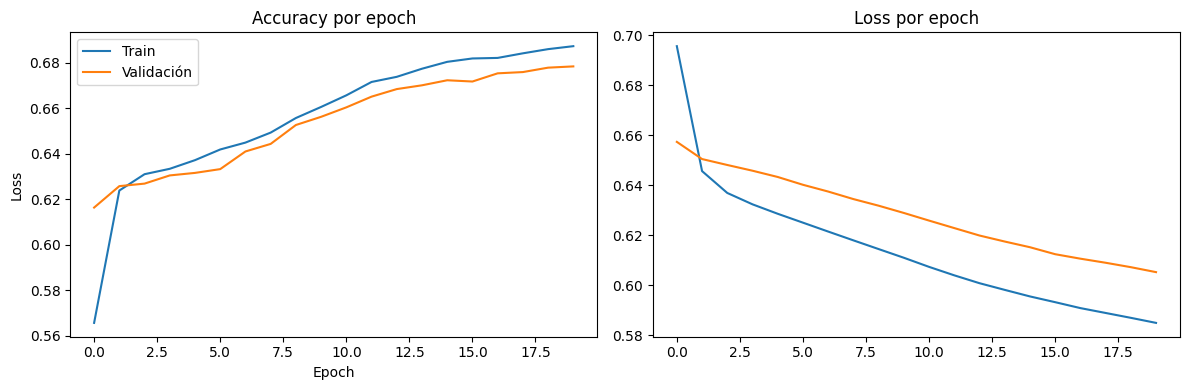

In [27]:
# Graficar el historial para ver si hay sobreajuste

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,4))

# Accuracy
ax1.plot(historia.history["accuracy"], label="Train")
ax1.plot(historia.history["val_accuracy"], label="Validación")
ax1.set_title("Accuracy por epoch")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy")
ax1.legend()

# Loss
ax2.plot(historia.history["loss"], label="Train")
ax2.plot(historia.history["val_loss"], label="Validación")
ax2.set_title("Loss por epoch")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()

plt.tight_layout()
plt.show()


In [28]:
# Evaluación de Keras

y_prob_keras = modelo_keras.predict(X_val_scaled).flatten()
y_pred_keras = (y_prob_keras >0.5).astype(int)

print("=== Keras ===")
print(f"ROC-AUC: {roc_auc_score(y_val, y_prob_keras):.4f}")
print(f"F1:      {f1_score(y_val, y_pred_keras):.4f}")
print(f"\n{classification_report(y_val, y_pred_keras)}")

113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 938us/step
=== Keras ===
ROC-AUC: 0.7401
F1:      0.6703

              precision    recall  f1-score   support

           0       0.68      0.69      0.69      1843
           1       0.67      0.67      0.67      1764

    accuracy                           0.68      3607
   macro avg       0.68      0.68      0.68      3607
weighted avg       0.68      0.68      0.68      3607



## 8. Comparativa final: clásicos vs Keras

In [30]:


resultados_finales = {
    "Modelo": ["Regresión Logística", "Árbol de decisión", 
               "XGBoost", "LightGBM", "Keras (Red neuronal)"],
    "ROC-AUC": [
        roc_auc_score(y_val, y_prob_lr),
        roc_auc_score(y_val, y_prob_tree),
        roc_auc_score(y_val, y_prob_xgb),
        roc_auc_score(y_val, y_prob_lgbm),
        roc_auc_score(y_val, y_prob_keras)
    ],
    "F1": [
        f1_score(y_val, y_pred_lr),
        f1_score(y_val, y_pred_tree),
        f1_score(y_val, y_pred_xgb),
        f1_score(y_val, y_pred_lgbm),
        f1_score(y_val, y_pred_keras)
    ],
    "Accuracy": [0.62, 0.71, 0.74, 0.74, 0.68]
}

df_final = pd.DataFrame(resultados_finales).round(4)
print(df_final)

                 Modelo  ROC-AUC      F1  Accuracy
0   Regresión Logística   0.6600  0.6405      0.62
1     Árbol de decisión   0.7777  0.7259      0.71
2               XGBoost   0.8277  0.7372      0.74
3              LightGBM   0.8331  0.7454      0.74
4  Keras (Red neuronal)   0.7401  0.6703      0.68


## 8. Comparativa final: clásicos vs Keras

| Modelo              | ROC-AUC | F1     | Accuracy |
|---------------------|---------|--------|----------|
| Regresión Logística | 0.66    | 0.64   | 0.62     |
| Árbol de decisión   | 0.78    | 0.73   | 0.71     |
| XGBoost             | 0.83    | 0.74   | 0.74     |
| LightGBM            | 0.83    | 0.75   | 0.74     |
| Keras               | 0.74    | 0.67   | 0.68     |

**Conclusión:** LightGBM es el modelo ganador con ROC-AUC de 0.83 y 
accuracy de 74%. XGBoost obtiene resultados prácticamente idénticos.

Los modelos de gradient boosting superan a Keras en este problema 
porque los datos son tabulares y estructurados, donde las relaciones 
entre features son relativamente directas. Keras necesita más datos 
y arquitecturas más complejas para superar a los árboles en datos 
tabulares.

**¿Cuándo usar Keras en vez de gradient boosting?**
- Imágenes → CNNs (redes convolucionales)
- Texto → RNNs, Transformers
- Audio → redes especializadas
- Datos tabulares con millones de filas → puede competir
- Datos tabulares medianos como este → gradient boosting gana casi siempre

## Evaluación final en test

In [31]:
y_pred_test = lgbm.predict(X_test_scaled)
y_prob_test = lgbm.predict_proba(X_test_scaled)[:,1]

print("=== Evaluación final en TEST — LightGBM ===")
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_test):.4f}")
print(f"F1:      {f1_score(y_test, y_pred_test):.4f}")
print(f"\n{classification_report(y_test, y_pred_test)}")

=== Evaluación final en TEST — LightGBM ===
ROC-AUC: 0.8319
F1:      0.7552

              precision    recall  f1-score   support

           0       0.77      0.73      0.75      1842
           1       0.73      0.78      0.76      1765

    accuracy                           0.75      3607
   macro avg       0.75      0.75      0.75      3607
weighted avg       0.75      0.75      0.75      3607



c:\Users\jaime\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\jaime\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
